# **LangGraph Concepts**
*In langgraph, stateful workflows are represented as directed graphs.*

## **LangGraph's Core Philosophy**

> *Make state explicit. Make flow visual. Make failures survivable.*

- **Explicit state**: Every piece of information lives in a typed, shared state object. No hidden variables, no prompt stuffing.
- **Graph-first design**: Draw your workflow first, then code it. The graph IS the documentation.
- **Persistence by default**: Workflows can be paused, inspected, replayed, and resumed at any checkpoint.

<br>

## **LangGraph Components**
### **STATE:**

It is the data that flows through different steps of the workflow. It's like a shared notebook that acts as a single source of truth that every node reads from and writes to

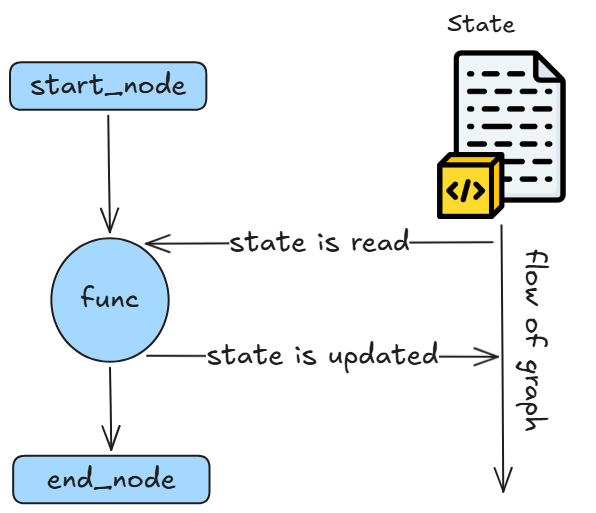

### **Installation**

In [26]:
!pip install -q langchain langchain-groq langgraph pygithub langchain-community

### **Defining States**

In [27]:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages
from langchain_core.messages import BaseMessage

# Simple state — plain key-value
class SimpleState(TypedDict):
    topic: str
    draft: str
    score: int
    approved: bool

# Message-aware state (for conversational agents)
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    # add_messages is a REDUCER — it appends new messages instead of overriding
    context: str
    iteration: int

## Setting up Groq for LLM Inference

**💡What is Groq?**

A platform that serves LLMs and provides access to OpenSource models in their freetier

---

**💡How to access models on Groq?**
 1. Visit : https://console.groq.com/keys
 2. Create an account using your email ID
 3. Click on the "Create API Key" button and enter a name for the key (we are using "CB_LangChain"
 4. Copy the generated key and paste it some where save
 5. Run the code below and paste the groq API Key in the text box

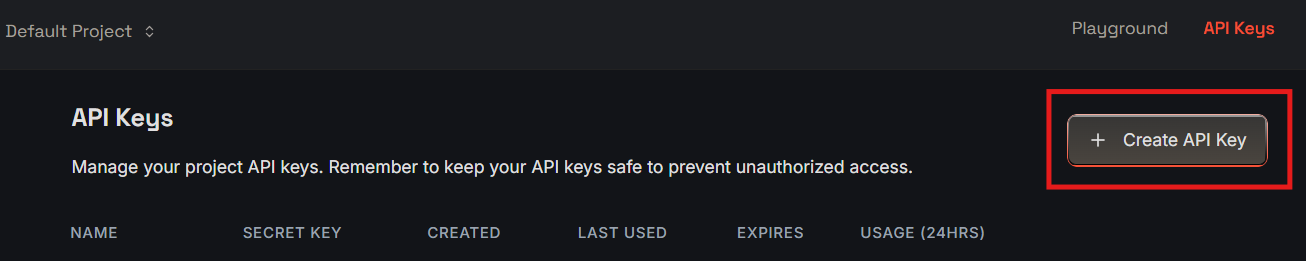

In [28]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

In [29]:
from langchain_core.messages import SystemMessage

from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

### **NODE**
A node is any python function that operate on the data (state) or perform some action.

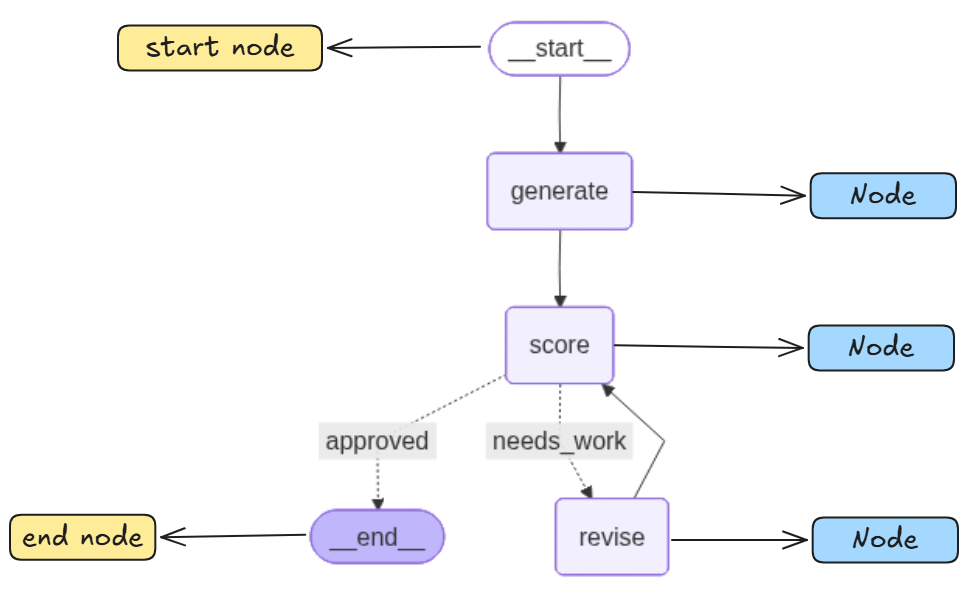


In [30]:
# Node 1 — Simple LLM call
def generate_draft(state: SimpleState) -> dict:
    """Writes a first draft on the given topic."""
    response = llm.invoke(f"Write a short paragraph about: {state['topic']}")
    return {"draft": response.content, "iteration": 1}

# Node 2 — Scoring agent
def score_draft(state: SimpleState) -> dict:
    """Scores the draft quality from 1–10."""
    prompt = f"""
    Rate this paragraph from 1–10 for clarity. Respond with ONLY a number.
    Paragraph: {state['draft']}
    """
    score = int(llm.invoke(prompt).content.strip())
    return {"score": score}

# Node 3 — Revision agent
def revise_draft(state: SimpleState) -> dict:
    """Improves a low-scoring draft."""
    response = llm.invoke(
        f"Improve this paragraph for clarity:\n{state['draft']}"
    )
    return {"draft": response.content}

**Registering functions as nodes**

In [31]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(SimpleState)

builder.add_node("generate", generate_draft)
builder.add_node("score", score_draft)
builder.add_node("revise", revise_draft)

###  **EDGES**
Edges connect nodes and tell LangGraph what happens after each step.

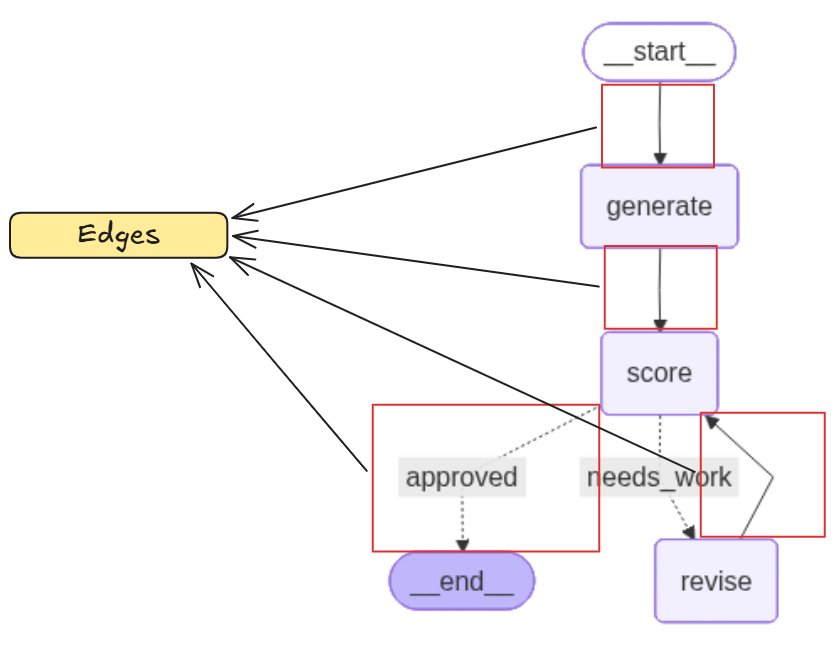

In [32]:
builder.add_edge(START, "generate")
builder.add_edge("generate", "score")
builder.add_edge("revise", "score")

**Conditional Edges**

Conditional edges call a routing function that looks at state and returns the name of the next node.

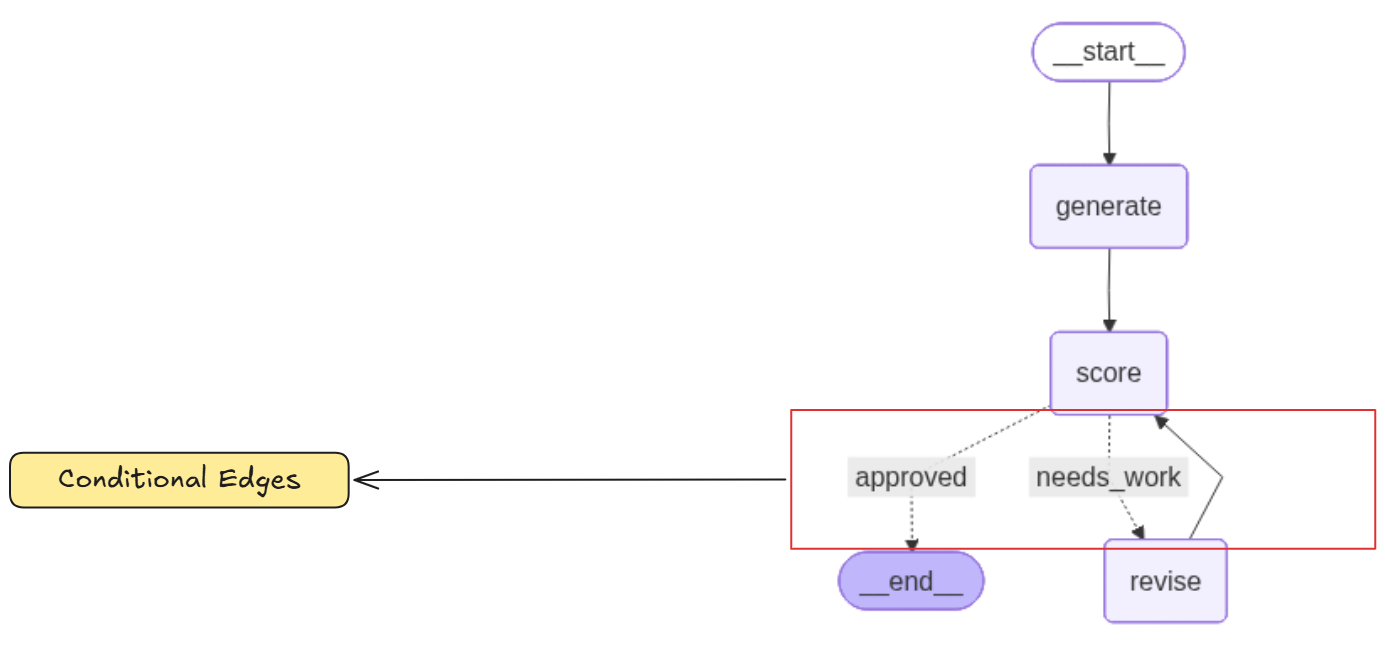

In [33]:
def quality_gate(state: SimpleState) -> str:
    """Route based on quality score."""
    if state["score"] >= 7:
        return "approved"
    elif state["iteration"] >= 3:
        return "give_up"
    else:
        return "needs_work"

builder.add_conditional_edges(
    "score",
    quality_gate,
    {
        "approved":   END,
        "give_up":    END,
        "needs_work": "revise",
    }
)

**Compile, Vizualize & Run the Graph**

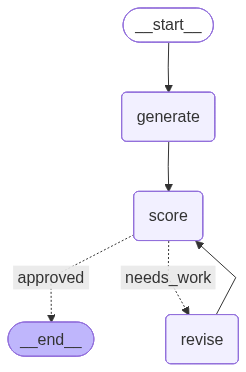

# Output
Quantum computing is an emerging field that leverages the principles of quantum mechanics to perform computations beyond the reach of classical computers. Unlike traditional computers that use bits as binary units (0 or 1), quantum computers utilize qubits, which can exist in a superposition of both states simultaneously. This allows quantum systems to process vast amounts of information in parallel. Additionally, qubits can be entangled, meaning the state of one qubit is intrinsically linked to another, enabling instantaneous correlations regardless of distance. These properties hold promise for solving complex problems in cryptography, material science, optimization, and drug discovery. However, challenges such as qubit stability, error correction, and decoherence remain significant hurdles. Companies and researchers worldwide are actively advancing quantum hardware and algorithms, aiming to unlock transformative applications across industries.


In [34]:
graph = builder.compile()

# Visualize (in Jupyter)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

# Run
result = graph.invoke({"topic": "quantum computing", "draft": "", "score": 0, "approved": False})

print("# Output")
print(result["draft"])

You can add memory to your graph via:

```python
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)
```

### **Human In The Loop**

In production agentic systems, you almost always need a human to review or approve before a consequential action. LangGraph's HITL support is built on two primitives:

- `interrupt(payload)`: Pauses the graph mid-node and surfaces a value to the caller

- `Command(resume=value)`: Resumes the graph, injecting the human's response back into the node

<br>

**NOTE**: The graph can only pause if it has a checkpointer (only then it can save the frozen state)

### **The Workflow: AI Email Drafting Assistant**
We'll build an agent that:

- Drafts an email from a short user instruction
- Pauses and shows the draft to the human
- Branches based on the human's decision — approve, edit, or discard
- Sends the email only when explicitly approved

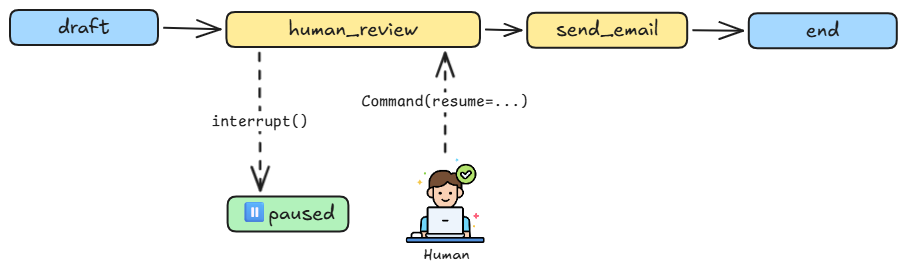


In [35]:
from typing import TypedDict, Annotated, Literal
from langchain_core.messages import BaseMessage
from langgraph.graph import add_messages

class EmailState(TypedDict):
    instruction: str
    # The LLM-generated draft
    draft_subject: str
    draft_body:    str
    decision: str
    edited_body: str
    messages: Annotated[list[BaseMessage], add_messages] # Remember our reducer?

In [36]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.types import interrupt

# Node 1: draft the email
def draft_email(state: EmailState) -> dict:
    """LLM writes a subject + body from the user's instruction."""
    system = SystemMessage(content="""
    You are an expert email writer. Given an instruction, write a professional email.
    Respond in this exact format:
    SUBJECT: <subject line>
    BODY:
    <email body>
    """)
    user = HumanMessage(content=f"Instruction: {state['instruction']}")
    response = llm.invoke([system, user])

    # Parse the structured response
    lines = response.content.strip().split("\n")
    subject = ""
    body_lines = []
    in_body = False

    for line in lines:
        if line.startswith("SUBJECT:"):
            subject = line.replace("SUBJECT:", "").strip()
        elif line.startswith("BODY:"):
            in_body = True
        elif in_body:
            body_lines.append(line)

    return {
        "draft_subject": subject,
        "draft_body":    "\n".join(body_lines).strip(),
        "messages":      [user, AIMessage(content=response.content)],
    }


# Node 2: get human review: this is where our graph will pause
def human_review(state: EmailState) -> dict:
    """
    Pauses the graph and surfaces the draft to the human.
    The human can respond with:
      - {"decision": "approve"}
      - {"decision": "edit", "edited_body": "...new body text..."}
      - {"decision": "discard"}
    """
    human_input = interrupt({
        "draft_subject": state["draft_subject"],
        "draft_body":    state["draft_body"],
        "prompt":        "Review this draft. Reply with approve / edit / discard.",
    })

    # human_input is whatever value was passed to Command(resume=...)
    decision    = human_input.get("decision", "discard")
    edited_body = human_input.get("edited_body", "")

    return {"decision": decision, "edited_body": edited_body}


# Node 3: sending email
def send_email(state: EmailState) -> dict:
    """Sends the approved (or edited) email."""
    final_body = state["edited_body"] if state["edited_body"] else state["draft_body"]
    print(f"\n📧 EMAIL SENT")
    print(f"   Subject : {state['draft_subject']}")
    print(f"   Body    :\n{final_body}")
    return {"messages": [AIMessage(content=f"Email sent: {state['draft_subject']}")]}


# Node 4: Discard email
def discard_email(state: EmailState) -> dict:
    """Human chose not to send the email."""
    print("\n🗑️  Email discarded by user.")
    return {"messages": [AIMessage(content="Email discarded.")]}

In [37]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

def route_after_review(state: EmailState) -> Literal["send_email", "discard_email"]:
    """Branch based on the human's decision."""
    if state["decision"] == "approve":
        return "send_email"
    elif state["decision"] == "edit":
        return "send_email"
    else:
        return "discard_email"

In [38]:
# Build
builder = StateGraph(EmailState)
builder.add_node("draft_email",   draft_email)
builder.add_node("human_review",  human_review)
builder.add_node("send_email",    send_email)
builder.add_node("discard_email", discard_email)

In [39]:
builder.add_edge(START,          "draft_email")
builder.add_edge("draft_email",  "human_review")
builder.add_conditional_edges(
    "human_review",
    route_after_review,
    {"send_email": "send_email", "discard_email": "discard_email"},
)
builder.add_edge("send_email",    END)
builder.add_edge("discard_email", END)

# ⚠️  MemorySaver is REQUIRED — HITL needs a place to save frozen state
memory  = MemorySaver()
graph   = builder.compile(checkpointer=memory)

In [40]:
from langgraph.types import Command

config = {"configurable": {"thread_id": "email-session-001"}}

initial_state = {
    "instruction":    "Write an email to the team announcing our product launch next Friday.",
    "draft_subject":  "",
    "draft_body":     "",
    "decision":       "",
    "edited_body":    "",
    "messages":       [],
}

Running our graph and waiting for interrupt

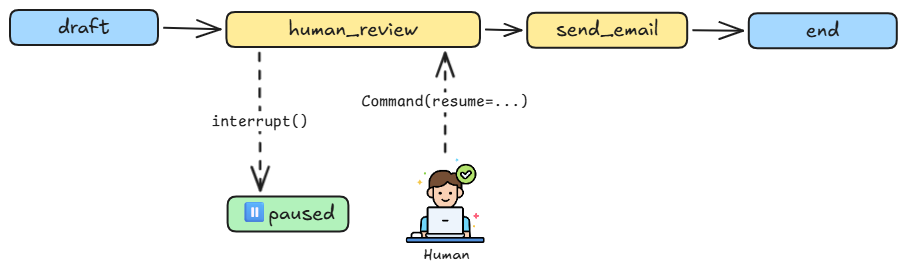

In [41]:
print("🤖 Drafting email...\n")


graph.invoke(initial_state, config=config)
snapshot = graph.get_state(config) # get current state of the graph
pending  = snapshot.next
review_payload = snapshot.values
print(f"\n⏸️  Graph paused at: {pending}")
print(f"\n{'='*50}")
print(f"  SUBJECT : {review_payload['draft_subject']}")
print(f"  BODY    :\n{review_payload['draft_body']}")
print(f"{'='*50}")

🤖 Drafting email...


⏸️  Graph paused at: ('human_review',)

  SUBJECT : Exciting News: Product Launch Scheduled for Next Friday!
  BODY    :
Dear Team,  

We’re thrilled to announce that our highly anticipated product, **[Product Name]**, will officially launch next Friday, **[Date]**! This milestone marks the culmination of our hard work, collaboration, and dedication to delivering innovative solutions to our customers.  

**[Product Name]** is designed to [briefly describe key features/benefits, e.g., "streamline workflow efficiency" or "enhance user experience through cutting-edge technology"]. We’re confident it will set a new standard in our industry and drive significant value for our clients.  

**Next Steps:**  
- Final testing and quality assurance will be completed by Thursday.  
- A team-wide briefing will be held tomorrow at 10 AM to review launch protocols.  
- Marketing and sales teams, please ensure all materials and training are finalized by EOD Thursday.  

Let’s com

We make a decision using the `Command` call.

In [42]:
graph.invoke(
    Command(resume={"decision": "approve"}),
    config=config,
)


📧 EMAIL SENT
   Subject : Exciting News: Product Launch Scheduled for Next Friday!
   Body    :
Dear Team,  

We’re thrilled to announce that our highly anticipated product, **[Product Name]**, will officially launch next Friday, **[Date]**! This milestone marks the culmination of our hard work, collaboration, and dedication to delivering innovative solutions to our customers.  

**[Product Name]** is designed to [briefly describe key features/benefits, e.g., "streamline workflow efficiency" or "enhance user experience through cutting-edge technology"]. We’re confident it will set a new standard in our industry and drive significant value for our clients.  

**Next Steps:**  
- Final testing and quality assurance will be completed by Thursday.  
- A team-wide briefing will be held tomorrow at 10 AM to review launch protocols.  
- Marketing and sales teams, please ensure all materials and training are finalized by EOD Thursday.  

Let’s come together to make this launch a resounding su

{'instruction': 'Write an email to the team announcing our product launch next Friday.',
 'draft_subject': 'Exciting News: Product Launch Scheduled for Next Friday!',
 'draft_body': 'Dear Team,  \n\nWe’re thrilled to announce that our highly anticipated product, **[Product Name]**, will officially launch next Friday, **[Date]**! This milestone marks the culmination of our hard work, collaboration, and dedication to delivering innovative solutions to our customers.  \n\n**[Product Name]** is designed to [briefly describe key features/benefits, e.g., "streamline workflow efficiency" or "enhance user experience through cutting-edge technology"]. We’re confident it will set a new standard in our industry and drive significant value for our clients.  \n\n**Next Steps:**  \n- Final testing and quality assurance will be completed by Thursday.  \n- A team-wide briefing will be held tomorrow at 10 AM to review launch protocols.  \n- Marketing and sales teams, please ensure all materials and tra

In [43]:
# Scenario 2 : Edit the body then approve
graph.invoke(
    Command(resume={
        "decision":    "edit",
        "edited_body": "Hi team,\nBig news — we're launching next Friday at 10am IST!\nStay tuned.\n— The Team",
    }),
    config=config,
)

{'instruction': 'Write an email to the team announcing our product launch next Friday.',
 'draft_subject': 'Exciting News: Product Launch Scheduled for Next Friday!',
 'draft_body': 'Dear Team,  \n\nWe’re thrilled to announce that our highly anticipated product, **[Product Name]**, will officially launch next Friday, **[Date]**! This milestone marks the culmination of our hard work, collaboration, and dedication to delivering innovative solutions to our customers.  \n\n**[Product Name]** is designed to [briefly describe key features/benefits, e.g., "streamline workflow efficiency" or "enhance user experience through cutting-edge technology"]. We’re confident it will set a new standard in our industry and drive significant value for our clients.  \n\n**Next Steps:**  \n- Final testing and quality assurance will be completed by Thursday.  \n- A team-wide briefing will be held tomorrow at 10 AM to review launch protocols.  \n- Marketing and sales teams, please ensure all materials and tra

In [44]:
# Scenario 3 : Discard
graph.invoke(
    Command(resume={"decision": "discard"}),
    config=config,
)

{'instruction': 'Write an email to the team announcing our product launch next Friday.',
 'draft_subject': 'Exciting News: Product Launch Scheduled for Next Friday!',
 'draft_body': 'Dear Team,  \n\nWe’re thrilled to announce that our highly anticipated product, **[Product Name]**, will officially launch next Friday, **[Date]**! This milestone marks the culmination of our hard work, collaboration, and dedication to delivering innovative solutions to our customers.  \n\n**[Product Name]** is designed to [briefly describe key features/benefits, e.g., "streamline workflow efficiency" or "enhance user experience through cutting-edge technology"]. We’re confident it will set a new standard in our industry and drive significant value for our clients.  \n\n**Next Steps:**  \n- Final testing and quality assurance will be completed by Thursday.  \n- A team-wide briefing will be held tomorrow at 10 AM to review launch protocols.  \n- Marketing and sales teams, please ensure all materials and tra

### **Subgraphs: Modular Workflow Designs**

Subgraphs let you encapsulate a complete workflow as a single reusable node inside a parent graph. This enables true hierarchical multi-agent systems & workflows

Each specialist team is its own graph, plugged into an orchestrating parent.

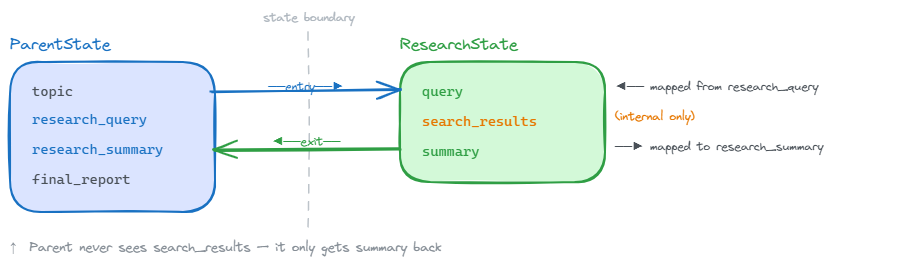

In [45]:
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)


# STATE
class ResearchState(TypedDict):
    query:          str        # ← receives research_query from parent (name must match)
    search_results: list[str]  # internal — parent never sees this
    summary:        str        # ← returned to parent as research_summary (name must match)

# NODES
def search_web(state: ResearchState) -> dict:
    """Simulate a web search — replace with a real tool in production."""
    print(f"  🔍 [search]    Searching for: '{state['query']}'")
    # Simulate three search result snippets
    mock_results = [
        f"Recent study: {state['query']} has seen 40% growth in adoption.",
        f"Industry report: {state['query']} is being used by 73% of Fortune 500 firms.",
        f"Expert opinion: {state['query']} will reshape the field within 5 years.",
    ]
    return {"search_results": mock_results}

def summarize_results(state: ResearchState) -> dict:
    """Ask the LLM to synthesize the search results into a tight summary."""
    print(f"  📝 [summarize] Synthesizing {len(state['search_results'])} results...")
    joined = "\n".join(f"- {r}" for r in state["search_results"])
    prompt = f"Summarize these findings into 2 concise sentences:\n{joined}"
    summary = llm.invoke(prompt).content
    return {"summary": summary}

# Register Nodes
research_builder = StateGraph(ResearchState)
research_builder.add_node("search",    search_web)
research_builder.add_node("summarize", summarize_results)

# EDGES
research_builder.add_edge(START,       "search")
research_builder.add_edge("search",    "summarize")
research_builder.add_edge("summarize", END)

research_subgraph = research_builder.compile()

In [46]:
sub_result = research_subgraph.invoke({"query": "LangGraph in production"})

print("\n── Subgraph standalone test ──")
print("Search results :", sub_result["search_results"])
print("Summary        :", sub_result["summary"])

  🔍 [search]    Searching for: 'LangGraph in production'
  📝 [summarize] Synthesizing 3 results...

── Subgraph standalone test ──
Search results : ['Recent study: LangGraph in production has seen 40% growth in adoption.', 'Industry report: LangGraph in production is being used by 73% of Fortune 500 firms.', 'Expert opinion: LangGraph in production will reshape the field within 5 years.']
Summary        : A recent study reveals a 40% rise in LangGraph adoption, with 73% of Fortune 500 companies now using it in production. Experts anticipate it will transform the field within five years.


**Defining the parent graph**

In [47]:
# STATE (parent)
class ReportState(TypedDict):
    topic:            str   # user's input
    research_query:   str   # prepared query — passed INTO subgraph as `query`
    research_summary: str   # summary returned FROM subgraph
    final_report:     str   # written by write_report node


# NODES
def prep_query(state: ReportState) -> dict:
    """Format the topic into a research query before handing off to subgraph."""
    print(f"\n🗂️  [prep_query] Topic: '{state['topic']}'")
    return {"research_query": f"enterprise adoption of {state['topic']} in 2025"}

def write_report(state: ReportState) -> dict:
    """Takes the subgraph's summary and writes a structured report."""
    print(f"\n✍️  [write_report] Writing final report...")
    prompt = f"""
    Write a short professional report (3 paragraphs) on the topic: "{state['topic']}".
    Use this research summary as your factual basis:
    {state['research_summary']}
    """
    report = llm.invoke(prompt).content
    return {"final_report": report}

### **Subgraph input/output key mapping**
The subgraph expects `query` but our parent state has `research_query`.

We wrap the subgraph in a thin adapter node to bridge the key mismatch.


In [48]:
def run_research_subgraph(state: ReportState) -> dict:
    """
    Adapter node — translates parent state keys into subgraph state keys,
    invokes the subgraph, then maps results back to parent state keys.
    """
    print(f"\n🔬 [research]   Handing off to research subgraph...")
    sub_input  = {"query": state["research_query"]}
    sub_output = research_subgraph.invoke(sub_input)
    return {"research_summary": sub_output["summary"]}

# NODES
parent_builder = StateGraph(ReportState)
parent_builder.add_node("prep_query", prep_query)
parent_builder.add_node("research",   run_research_subgraph)  # ← adapter wraps subgraph
parent_builder.add_node("write",      write_report)

# EDGES
parent_builder.add_edge(START,        "prep_query")
parent_builder.add_edge("prep_query", "research")
parent_builder.add_edge("research",   "write")
parent_builder.add_edge("write",       END)

report_graph = parent_builder.compile()

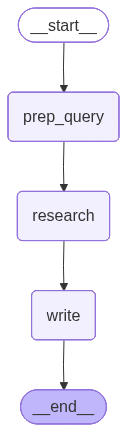

In [50]:
from IPython.display import Image, display
display(Image(report_graph.get_graph().draw_mermaid_png()))

In [49]:
initial_state = {
    "topic":            "LangGraph",
    "research_query":   "",
    "research_summary": "",
    "final_report":     "",
}

print("🚀 Starting Report Generator\n" + "="*50)

result = report_graph.invoke(initial_state)

print("\n" + "="*50)
print("📊 FINAL REPORT")
print("="*50)
print(result["final_report"])

🚀 Starting Report Generator

🗂️  [prep_query] Topic: 'LangGraph'

🔬 [research]   Handing off to research subgraph...
  🔍 [search]    Searching for: 'enterprise adoption of LangGraph in 2025'
  📝 [summarize] Synthesizing 3 results...

✍️  [write_report] Writing final report...

📊 FINAL REPORT
**LangGraph: A Catalyst for Enterprise AI Transformation**  

LangGraph, a framework designed to streamline the development and deployment of AI-driven applications, has experienced a remarkable surge in enterprise adoption in 2025. Recent industry reports highlight a 40% year-over-year growth in its usage, with 73% of Fortune 500 companies now leveraging its capabilities. This rapid uptake underscores LangGraph’s role in enabling organizations to integrate large language models (LLMs) into complex workflows, automate decision-making processes, and enhance operational efficiency. Its modular architecture and compatibility with existing enterprise systems have positioned it as a critical tool for bu